# Double Pendulum — ML Method Comparison

Comparing four machine learning approaches for learning the dynamics of the double pendulum:

| Model | Key Idea |
|---|---|
| **MLP** | Baseline: directly maps state_t → state_{t+1} |
| **ResNet** | Residual connections: models the change δx |
| **Neural ODE** | Learns f in dx/dt = f(x), integrates with RK4 |
| **HNN** | Learns scalar H(q,p), derives dynamics via autograd |

**Metrics:** short-term MSE, long-term rollout MSE, energy conservation error.

## 0. Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.integrate import solve_ivp
import time

DEVICE = "cpu"

try:
    from torchdiffeq import odeint
    HAS_TORCHDIFFEQ = True
    print("torchdiffeq: available ✓")
except ImportError:
    HAS_TORCHDIFFEQ = False
    print("torchdiffeq: not found — NeuralODE will use Euler fallback")

COLORS = {"MLP": "#E63946", "ResNet": "#F4A261", "NeuralODE": "#2A9D8F", "HNN": "#457B9D"}
DT = 0.02

Using device: cpu
torchdiffeq: not found — NeuralODE will use Euler fallback


## 1. Data Generation — Double Pendulum Simulation

In [3]:
G  = 9.81
L1 = L2 = M1 = M2 = 1.0


def double_pendulum_ode(t, y):
    th1, th2, w1, w2 = y
    delta = th2 - th1

    denom1 = (M1 + M2) * L1 - M2 * L1 * np.cos(delta) ** 2
    denom2 = (L2 / L1) * denom1

    dw1 = (
        M2 * L1 * w1**2 * np.sin(delta) * np.cos(delta)
        + M2 * G * np.sin(th2) * np.cos(delta)
        + M2 * L2 * w2**2 * np.sin(delta)
        - (M1 + M2) * G * np.sin(th1)
    ) / denom1

    dw2 = (
        -M2 * L2 * w2**2 * np.sin(delta) * np.cos(delta)
        + (M1 + M2) * G * np.sin(th1) * np.cos(delta)
        - (M1 + M2) * L1 * w1**2 * np.sin(delta)
        - (M1 + M2) * G * np.sin(th2)
    ) / denom2

    return [w1, w2, dw1, dw2]


def hamiltonian(y):
    th1, th2, w1, w2 = y[..., 0], y[..., 1], y[..., 2], y[..., 3]
    delta = th2 - th1
    T = (
        0.5 * M1 * (L1 * w1) ** 2
        + 0.5 * M2 * ((L1 * w1)**2 + (L2 * w2)**2 + 2*L1*L2*w1*w2*np.cos(delta))
    )
    V = -(M1 + M2) * G * L1 * np.cos(th1) - M2 * G * L2 * np.cos(th2)
    return T + V


def simulate_trajectory(y0, t_span=(0, 10), dt=DT):
    t_eval = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(double_pendulum_ode, t_span, y0,
                    method="RK45", t_eval=t_eval, rtol=1e-10, atol=1e-10)
    return sol.t, sol.y.T


def generate_dataset(n_trajectories=200, t_span=(0, 10), train_ratio=0.8, seed=42):
    rng = np.random.default_rng(seed)
    all_data = []
    for _ in range(n_trajectories):
        y0 = [
            rng.uniform(-np.pi/2, np.pi/2),
            rng.uniform(-np.pi/2, np.pi/2),
            rng.uniform(-1.0, 1.0),
            rng.uniform(-1.0, 1.0),
        ]
        t, states = simulate_trajectory(y0, t_span=t_span)
        all_data.append((t, states))
    split = int(n_trajectories * train_ratio)
    return all_data[:split], all_data[split:]


def make_step_dataset(trajectories):
    Xs, Ys = [], []
    for _, states in trajectories:
        Xs.append(states[:-1])
        Ys.append(states[1:])
    X = np.concatenate(Xs, axis=0).astype(np.float32)
    Y = np.concatenate(Ys, axis=0).astype(np.float32)
    return X, Y


def make_derivative_dataset(trajectories):
    """(state, dx/dt) pairs for HNN training."""
    Xs, Ys = [], []
    for _, states in trajectories:
        diffs = np.gradient(states, DT, axis=0)
        Xs.append(states[:-1])
        Ys.append(diffs[:-1])
    X = np.concatenate(Xs, axis=0).astype(np.float32)
    Y = np.concatenate(Ys, axis=0).astype(np.float32)
    return X, Y


N_TRAJ  = 50
T_SPAN  = (0, 10)

print("Generating trajectories …")
t0 = time.time()
train_data, test_data = generate_dataset(n_trajectories=N_TRAJ, t_span=T_SPAN)
print(f"Done in {time.time()-t0:.1f}s | train={len(train_data)} test={len(test_data)}")

Generating trajectories …
Done in 18.3s | train=160 test=40


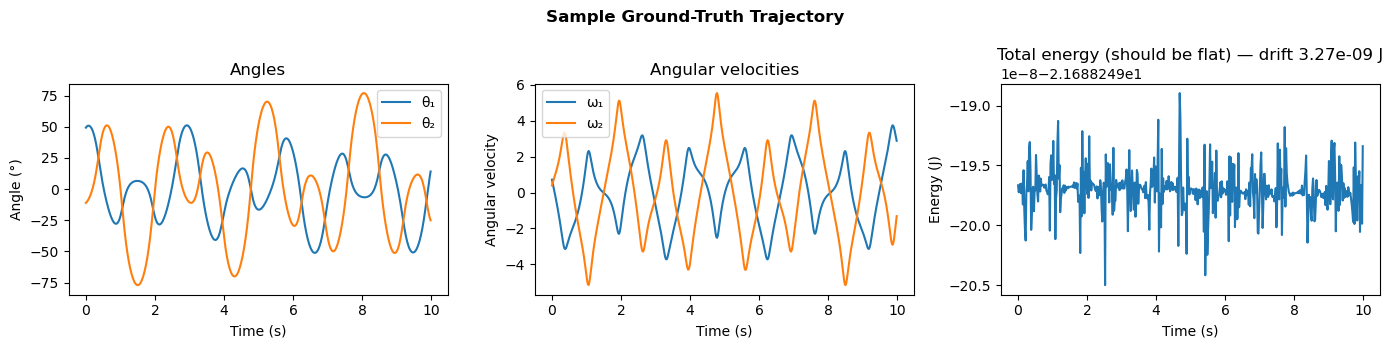

In [4]:
t_ex, s_ex = train_data[0]
E = hamiltonian(s_ex)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(t_ex, np.degrees(s_ex[:, 0]), label="θ₁")
axes[0].plot(t_ex, np.degrees(s_ex[:, 1]), label="θ₂")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Angle (°)")
axes[0].set_title("Angles"); axes[0].legend()

axes[1].plot(t_ex, s_ex[:, 2], label="ω₁")
axes[1].plot(t_ex, s_ex[:, 3], label="ω₂")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Angular velocity")
axes[1].set_title("Angular velocities"); axes[1].legend()

axes[2].plot(t_ex, E)
axes[2].set_xlabel("Time (s)"); axes[2].set_ylabel("Energy (J)")
axes[2].set_title(f"Total energy (should be flat) — drift {abs(E[-1]-E[0]):.2e} J")

plt.suptitle("Sample Ground-Truth Trajectory", fontweight="bold")
plt.tight_layout()
plt.savefig("images/sample_trajectory.png", dpi=150)
plt.show()

## 2. Model Definitions

In [5]:
class MLP(nn.Module):

    def __init__(self, state_dim=4, hidden_dim=256, n_layers=4):
        super().__init__()
        layers = [nn.Linear(state_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, state_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ResNet
class ResBlock(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, dim)
        )
    def forward(self, x):
        return x + self.block(x)


class ResNet(nn.Module):
    
    def __init__(self, state_dim=4, hidden_dim=256, n_blocks=4):
        super().__init__()
        self.input_proj  = nn.Linear(state_dim, hidden_dim)
        self.blocks      = nn.Sequential(*[ResBlock(hidden_dim, hidden_dim) for _ in range(n_blocks)])
        self.output_proj = nn.Linear(hidden_dim, state_dim)

    def forward(self, x):
        h = torch.tanh(self.input_proj(x))
        h = self.blocks(h)
        return self.output_proj(h)


# 2. Neural ODE
class ODEFunc(nn.Module):
    """Learned vector field f in dy/dt = f(y)"""
    def __init__(self, state_dim=4, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, state_dim),
        )
    def forward(self, t, y):
        return self.net(y)


class NeuralODE(nn.Module):
    def __init__(self, state_dim=4, hidden_dim=256):
        super().__init__()
        self.func = ODEFunc(state_dim, hidden_dim)

    def forward(self, y0, t):
        if HAS_TORCHDIFFEQ:
            return odeint(self.func, y0, t, method="rk4")
        else:
            ys = [y0]
            for i in range(len(t) - 1):
                dt = t[i+1] - t[i]
                ys.append(ys[-1] + dt * self.func(t[i], ys[-1]))
            return torch.stack(ys)

    def predict_next(self, y0, dt=DT):
        t = torch.tensor([0.0, dt], dtype=y0.dtype, device=y0.device)
        return self.forward(y0, t)[1]


# Hamiltonian Neural Network (HNN)
class HNN(nn.Module):
    
    def __init__(self, state_dim=4, hidden_dim=256, n_layers=3):
        super().__init__()
        layers = [nn.Linear(state_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.H_net = nn.Sequential(*layers)

    def hamiltonian(self, x):
        return self.H_net(x).squeeze(-1)

    def time_derivative(self, x):
        x = x.requires_grad_(True)
        H = self.hamiltonian(x).sum()
        grad = torch.autograd.grad(H, x, create_graph=True)[0]
        dqdt =  grad[:, 2:]    # ∂H/∂p
        dpdt = -grad[:, :2]    # -∂H/∂q
        return torch.cat([dqdt, dpdt], dim=-1)

    def forward(self, x):
        return self.time_derivative(x)

    def predict_next(self, x, dt=DT):
        """RK4 integration of learned Hamiltonian dynamics."""
        f = self.time_derivative
        k1 = f(x)
        k2 = f(x + 0.5*dt*k1)
        k3 = f(x + 0.5*dt*k2)
        k4 = f(x + dt*k3)
        return x + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)


print("Models defined ✓")

Models defined ✓


## 3. Training

In [6]:
EPOCHS     = 100
HIDDEN_DIM = 256
BATCH_SIZE = 256
LR         = 1e-3


def train_generic(model, X_train, Y_train, model_name, predict_fn=None):
    model = model.to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=100, gamma=0.5)
    loss_fn = nn.MSELoss()

    X_t = torch.tensor(X_train).to(DEVICE)
    Y_t = torch.tensor(Y_train).to(DEVICE)
    loader = DataLoader(TensorDataset(X_t, Y_t), batch_size=BATCH_SIZE, shuffle=True)

    losses = []
    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            pred = predict_fn(model, xb) if predict_fn else model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item() * len(xb)
        losses.append(total / len(X_t))
        sched.step()
        if epoch % 50 == 0:
            print(f"  [{model_name}] epoch {epoch:4d}/{EPOCHS} | loss {losses[-1]:.6f} | {time.time()-t0:.1f}s")
    return model, losses


X_step, Y_step = make_step_dataset(train_data)
X_deriv, Y_deriv = make_derivative_dataset(train_data)

all_losses = {}

print("\n--- MLP ---")
mlp, all_losses["MLP"] = train_generic(MLP(hidden_dim=HIDDEN_DIM), X_step, Y_step, "MLP")

print("\n--- ResNet ---")
resnet, all_losses["ResNet"] = train_generic(ResNet(hidden_dim=HIDDEN_DIM), X_step, Y_step, "ResNet")

print("\n--- NeuralODE ---")
node, all_losses["NeuralODE"] = train_generic(
    NeuralODE(hidden_dim=HIDDEN_DIM), X_step, Y_step, "NeuralODE",
    predict_fn=lambda m, x: m.predict_next(x)
)

print("\n--- HNN ---")
hnn, all_losses["HNN"] = train_generic(HNN(hidden_dim=HIDDEN_DIM), X_deriv, Y_deriv, "HNN")

print("\nAll models trained ✓")


--- MLP ---
  [MLP] epoch   50/300 | loss 0.001263 | 50.0s
  [MLP] epoch  100/300 | loss 0.001157 | 102.1s
  [MLP] epoch  150/300 | loss 0.000369 | 150.3s
  [MLP] epoch  200/300 | loss 0.000321 | 197.6s
  [MLP] epoch  250/300 | loss 0.000169 | 249.0s
  [MLP] epoch  300/300 | loss 0.000154 | 301.2s

--- ResNet ---
  [ResNet] epoch   50/300 | loss 0.000399 | 99.0s
  [ResNet] epoch  100/300 | loss 0.000408 | 197.4s
  [ResNet] epoch  150/300 | loss 0.000195 | 298.4s
  [ResNet] epoch  200/300 | loss 0.000152 | 460.1s
  [ResNet] epoch  250/300 | loss 0.000094 | 921.5s
  [ResNet] epoch  300/300 | loss 0.000098 | 1399.7s

--- NeuralODE ---
  [NeuralODE] epoch   50/300 | loss 0.000324 | 138.8s
  [NeuralODE] epoch  100/300 | loss 0.000316 | 285.0s
  [NeuralODE] epoch  150/300 | loss 0.000302 | 435.6s
  [NeuralODE] epoch  200/300 | loss 0.000301 | 560.0s
  [NeuralODE] epoch  250/300 | loss 0.000291 | 695.1s
  [NeuralODE] epoch  300/300 | loss 0.000292 | 853.3s

--- HNN ---
  [HNN] epoch   50/300

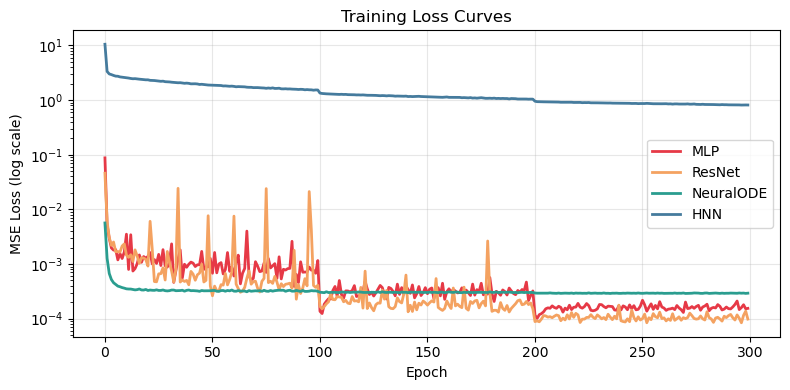

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, losses in all_losses.items():
    ax.semilogy(losses, label=name, color=COLORS[name], lw=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("Training Loss Curves"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/training_loss.png", dpi=150)
plt.show()

## 4. Evaluation

In [10]:
TRAINED_MODELS = {"MLP": mlp, "ResNet": resnet, "NeuralODE": node, "HNN": hnn}


def predict_next_state(model, name, x_np):
    x = torch.tensor(x_np, dtype=torch.float32, device=DEVICE)
    model.eval()
    if name in ("MLP", "ResNet"):
        with torch.no_grad():
            pred = model(x)
    else:
        pred = model.predict_next(x)
    return pred.detach().cpu().numpy()


def rollout(model, name, y0_np, n_steps):
    traj = [y0_np]
    cur  = y0_np[None]
    for _ in range(n_steps):
        nxt = predict_next_state(model, name, cur)
        traj.append(nxt[0])
        cur = nxt
    return np.array(traj)


N_ROLLOUT = 250

metrics = {}
for name, model in TRAINED_MODELS.items():
    short_mses, rollout_mse_curves, energy_err_curves = [], [], []

    for _, states in test_data:
        Y_pred = predict_next_state(model, name, states[:-1])
        short_mses.append(np.mean((Y_pred - states[1:]) ** 2))

        steps = min(N_ROLLOUT, len(states) - 1)
        pred_traj = rollout(model, name, states[0], steps)
        gt_traj   = states[:steps + 1]
        rollout_mse_curves.append(np.mean((pred_traj - gt_traj) ** 2, axis=1))

        E0 = hamiltonian(states[:1])[0]
        E_pred = hamiltonian(pred_traj)
        energy_err_curves.append(np.abs(E_pred - E0) / (np.abs(E0) + 1e-8))

    metrics[name] = {
        "short_mse":          float(np.mean(short_mses)),
        "rollout_mse_curve":  np.mean(rollout_mse_curves, axis=0),
        "energy_error_curve": np.mean(energy_err_curves, axis=0),
    }
    print(f"  {name:<12} | short-term MSE = {metrics[name]['short_mse']:.6f}")

  MLP          | short-term MSE = 0.004869
  ResNet       | short-term MSE = 0.003370
  NeuralODE    | short-term MSE = 0.000555
  HNN          | short-term MSE = 0.002897


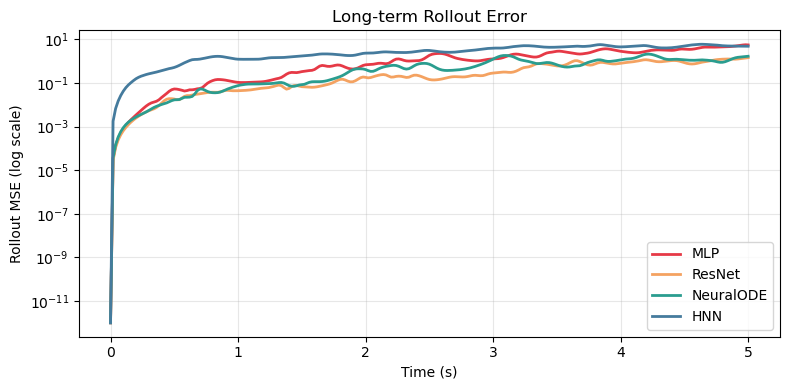

In [11]:
t_axis = np.arange(N_ROLLOUT + 1) * DT

fig, ax = plt.subplots(figsize=(8, 4))
for name, m in metrics.items():
    ax.semilogy(t_axis, m["rollout_mse_curve"] + 1e-12, label=name, color=COLORS[name], lw=2)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Rollout MSE (log scale)")
ax.set_title("Long-term Rollout Error"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/rollout_mse.png", dpi=150)
plt.show()

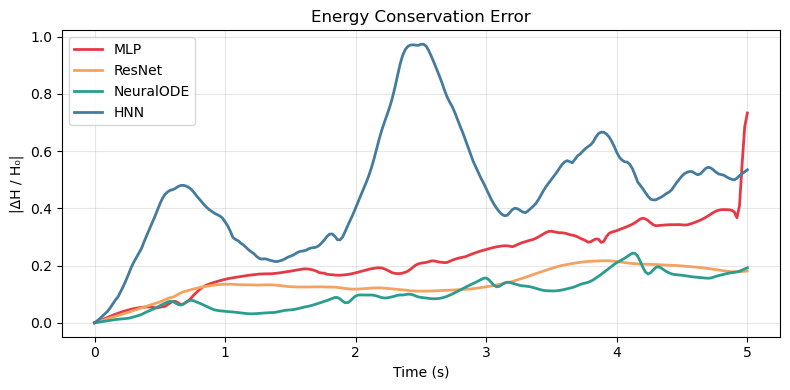

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, m in metrics.items():
    ax.plot(t_axis, m["energy_error_curve"], label=name, color=COLORS[name], lw=2)
ax.set_xlabel("Time (s)"); ax.set_ylabel("|ΔH / H₀|")
ax.set_title("Energy Conservation Error"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/energy_error.png", dpi=150)
plt.show()

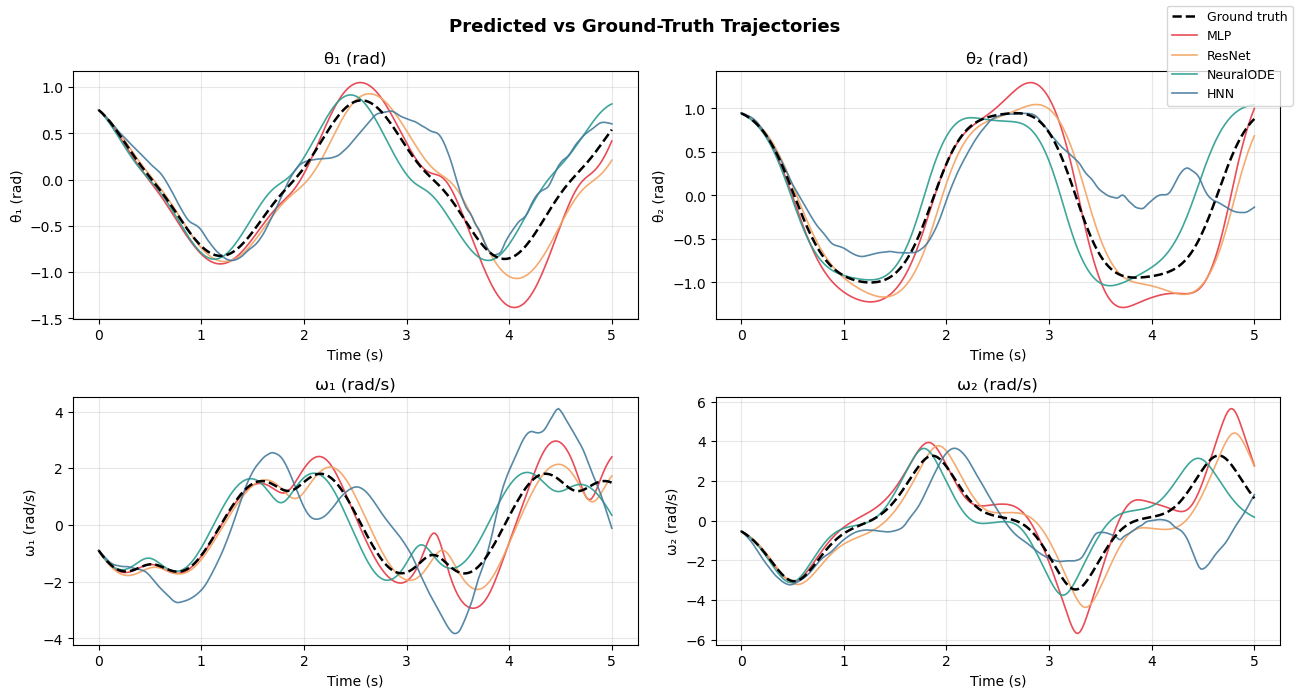

In [13]:
# ── Trajectory comparison ──────────────────────────────────────────────────────
_, gt_states = test_data[0]
n_steps = min(N_ROLLOUT, len(gt_states) - 1)
y0 = gt_states[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
labels = ["θ₁ (rad)", "θ₂ (rad)", "ω₁ (rad/s)", "ω₂ (rad/s)"]
t_plot = np.arange(n_steps + 1) * DT

for i, ax in enumerate(axes.flat):
    ax.plot(t_plot, gt_states[:n_steps+1, i], "k--", lw=1.8, label="Ground truth", zorder=5)
    for name, model in TRAINED_MODELS.items():
        pred_traj = rollout(model, name, y0, n_steps)
        ax.plot(t_plot, pred_traj[:, i], color=COLORS[name], lw=1.2, alpha=0.9, label=name)
    ax.set_xlabel("Time (s)"); ax.set_ylabel(labels[i])
    ax.set_title(labels[i]); ax.grid(True, alpha=0.3)

handles, lbls = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="upper right", fontsize=9)
plt.suptitle("Predicted vs Ground-Truth Trajectories", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/trajectory_comparison.png", dpi=150)
plt.show()

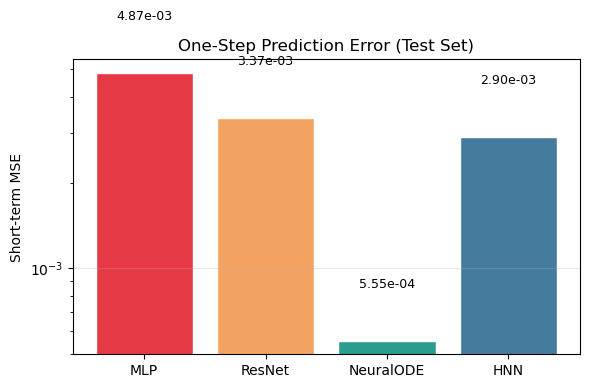

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
names = list(metrics.keys())
mses  = [metrics[n]["short_mse"] for n in names]
bars  = ax.bar(names, mses, color=[COLORS[n] for n in names], edgecolor="white")
ax.set_yscale("log")
ax.set_ylabel("Short-term MSE")
ax.set_title("One-Step Prediction Error (Test Set)")
for bar, val in zip(bars, mses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.5,
            f"{val:.2e}", ha="center", va="bottom", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("images/short_term_bar.png", dpi=150)
plt.show()

In [15]:
idx_4s = min(int(4.0 / DT), N_ROLLOUT)

print(f"{'Model':<12} | {'Short MSE':>12} | {'4s Energy Err':>15} | {'Final Energy Err':>18}")
print("-" * 65)
for name, m in metrics.items():
    e4  = m["energy_error_curve"][idx_4s]
    efin = m["energy_error_curve"][-1]
    print(f"{name:<12} | {m['short_mse']:>12.6f} | {e4:>15.6f} | {efin:>18.6f}")

Model        |    Short MSE |  Energy Err @4s |  Energy Err @final
-----------------------------------------------------------------
MLP          |     0.004869 |        0.322046 |           0.732811
ResNet       |     0.003370 |        0.213990 |           0.180964
NeuralODE    |     0.000555 |        0.210044 |           0.192023
HNN          |     0.002897 |        0.594886 |           0.534565
